In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

In [45]:
with np.load('../specfem2d_examples/seam/data_specfem_seam.npz') as data:
    vx_specfem = data['vx']
    vz_specfem = data['vz']
    dt_specfem = data['dt']
with np.load('../devito_examples/seam/data_devito_seam.npz') as data:
    vx_devito = data['vx']
    vz_devito = data['vz']
    dt_devito = data['dt']

In [46]:
time_specfem = np.arange(vx_specfem.shape[0]) * dt_specfem
time_devito = np.arange(vx_devito.shape[0]) * dt_devito * 1e-3  # Convert ms to s

# Use time specfem as reference
# Interpolate Devito data to Specfem time grid using scipy interp
from scipy.interpolate import interp1d
interp_vx = interp1d(time_devito, vx_devito, axis=0, kind='linear', fill_value='extrapolate')
interp_vz = interp1d(time_devito, vz_devito, axis=0, kind='linear', fill_value='extrapolate')
vx_devito_interp = interp_vx(time_specfem)
vz_devito_interp = interp_vz(time_specfem)

In [47]:
#Shift devito data in time and scaling amplitude to better match specfem data
time_shift = 0.017  # seconds
amplitude_scale = 900

vx_devito_interp = np.roll(vx_devito_interp, int(time_shift / dt_specfem), axis=0) * amplitude_scale * -1
vz_devito_interp = np.roll(vz_devito_interp, int(time_shift / dt_specfem), axis=0) * amplitude_scale

Text(0.5, 0, 'X (m)')

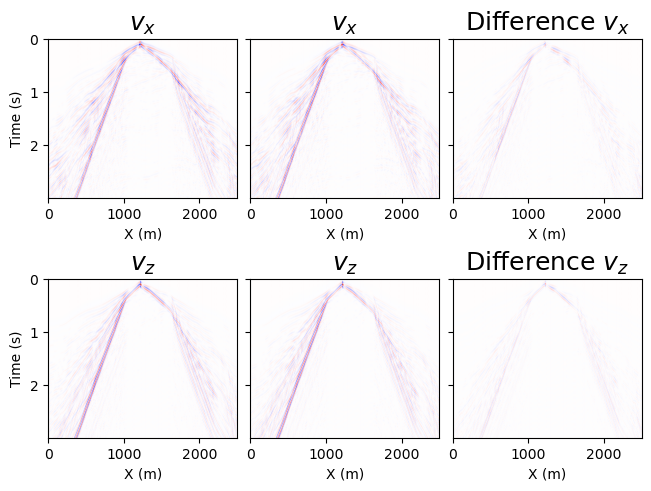

In [ ]:
pcx=np.max(np.abs(vx_specfem))
pcz=np.max(np.abs(vz_specfem))
xmin=120
xmax=5000
from devitocurvilinear import odt_seismics
cmap = 'gray'
cmap = 'seismic'
extent = [xmin, xmax, time_specfem[-1], time_specfem[0]]
fig1, ax = plt.subplots(2, 3, layout='constrained', sharey=True)
# VX
ax[0,0].set_title('$v_x$', fontsize=18)
ax[0,0].imshow(vx_devito_interp, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,0].set_ylabel('Time (s)')
ax[0,0].set_xlabel('X (m)')
ax[0,1].set_title('$v_x$', fontsize=18)
ax[0,1].imshow(-vx_specfem, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,1].set_xlabel('X (m)')
ax[0,2].set_title('Difference $v_x$', fontsize=18)
im = ax[0,2].imshow(vx_devito_interp - vx_specfem, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,2].set_xlabel('X (m)')
# VZ
ax[1,0].set_title('$v_z$', fontsize=18)
ax[1,0].imshow(vz_devito_interp, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,0].set_ylabel('Time (s)')
ax[1,0].set_xlabel('X (m)')
ax[1,1].set_title('$v_z$', fontsize=18)
ax[1,1].imshow(vz_specfem, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,1].set_xlabel('X (m)')
ax[1,2].set_title('Difference $v_z$', fontsize=18)
im = ax[1,2].imshow(vz_devito_interp - vz_specfem, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,2].set_xlabel('X (m)')

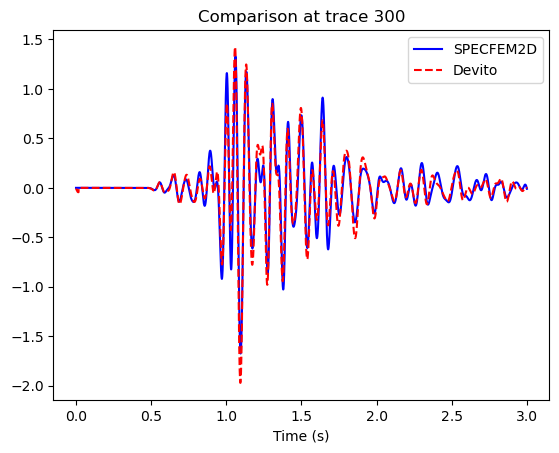

In [54]:
trace = 300
plt.plot(time_specfem, vx_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vx_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()

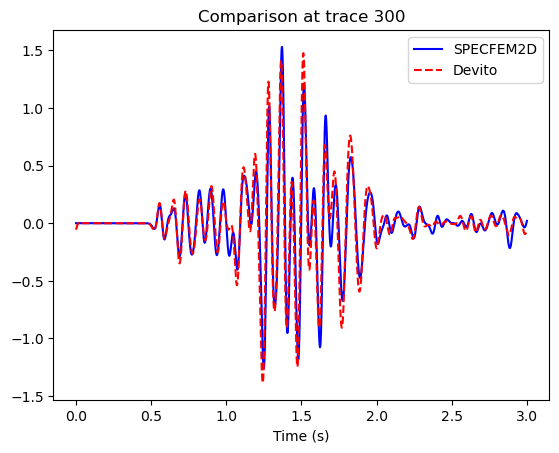

In [55]:
trace = 300
plt.plot(time_specfem, vz_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vz_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()